## Bulk correlator is plotted using lattice data from arxiv:2601.14967 

[[ 0.13888889 13.46217096]
 [ 0.16666667 14.38956143]
 [ 0.19444444 17.77067187]
 [ 0.22222222 19.05278678]
 [ 0.25       22.15923616]
 [ 0.27777778 27.17831235]
 [ 0.30555556 31.56797851]
 [ 0.33333333 37.33817113]
 [ 0.36111111 43.49098882]
 [ 0.38888889 51.81943037]
 [ 0.41666667 58.58061726]
 [ 0.44444444 64.83428839]
 [ 0.47222222 67.93177325]
 [ 0.5        68.57286284]]
[[ 0.13888889 11.42731422]
 [ 0.16666667 12.09373608]
 [ 0.19444444 14.40332127]
 [ 0.22222222 18.45022991]
 [ 0.25       22.11826879]
 [ 0.27777778 26.79331898]
 [ 0.30555556 29.80253748]
 [ 0.33333333 38.21047017]
 [ 0.36111111 46.41683506]
 [ 0.38888889 52.15052442]
 [ 0.41666667 60.40009114]
 [ 0.44444444 67.2558468 ]
 [ 0.47222222 73.97634029]
 [ 0.5        78.11017346]]
[[ 0.13888889  9.15383076]
 [ 0.16666667 11.0229018 ]
 [ 0.19444444 12.77200305]
 [ 0.22222222 14.60421024]
 [ 0.25       16.40262292]
 [ 0.27777778 19.22086293]
 [ 0.30555556 21.8870778 ]
 [ 0.33333333 25.09678091]
 [ 0.36111111 29.62188966]

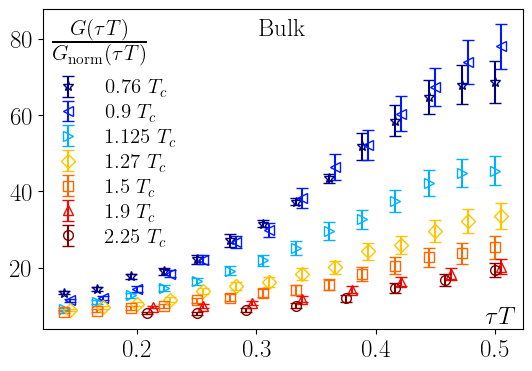

Process completed


In [5]:
from numpy import *
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig = plt.figure(figsize=(6, 4))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.rc('text',usetex=True) ; plt.rc('font',family='serif', size=18)
plt.rcParams['font.sans-serif'] = 'Times New Roman'
axes = plt.gca()

cm_subsection = hstack((linspace(0, 0.3, int(6 / 2)), linspace(0.70, 1.0, 4)))
colors = [cm.jet(x) for x in cm_subsection]
adjust_x = 0.005
temperatures = ['0_76', '0_9', '1_125', '1_2667', '1_5', '1_9', '2_25']
markers = ['*', '<', '>', 'D', 's', '^', 'o']

datas_bulk = []
for i, temperature in enumerate(temperatures):
    format_temperature = temperature.replace('_', '.')
    if format_temperature == '1.2667':
        format_temperature = '1.27'
    datas_bulk.append(loadtxt(f'./data/{temperature}Tc/{temperature}Tc_Corr_Bulk_Flow_Extrap_Separ_25_1.dat'))
    print(datas_bulk[i][:,0:2])
    plt.errorbar(datas_bulk[i][:, 0] + (i%2) * adjust_x, datas_bulk[i][:, 1], yerr=datas_bulk[i][:, 2], fmt=markers[i], markersize=7, markerfacecolor='none',
                 color=colors[i], capsize=4, label=rf'{format_temperature} $T_c$') # star
    
plt.xlabel(r'$\tau T$', labelpad=-40, position=(0.98, 0.15), ha='right', fontsize=18)
plt.ylabel(r'$\frac{G(\tau T)}{G_{\rm{norm}}(\tau T)}$', labelpad=-30, position=(0.15,0.97), ha='left', va='top', rotation=0, fontsize=22)
plt.text(0.5, 0.85, 'Bulk', fontsize=18, color='black',alpha=1, ha='center', va='center', transform=plt.gcf().transFigure, rotation=0)
plt.legend(loc='center left', frameon=False, bbox_to_anchor=(-0.03, 0.52), ncol=1, columnspacing=0.6, facecolor="white",
           labelspacing=0.3, fontsize=15)
name_fig = './figs/' + 'corr_bulk_extra_tf0_final_all_1_25_1.pdf'
plt.savefig(name_fig)
#plt.close()
#plt.clf()
plt.show()
print("Process completed")